## Employee Productivity Analysis

In [11]:
!pip install numpy pandas seaborn matplotlib scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
try:
    df = pd.read_csv('q1.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: Please upload the 'q1.xlsx' file.")

df.head()

Dataset loaded successfully!


,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
0,2,40,38,3,62
1,5,60,42,6,78
2,1,20,35,2,55
3,8,80,45,8,88
4,4,50,40,5,72


## 1. EDA

In [6]:
# Checking for missing values and data types
df.info()

# Statistical summary
display(df.describe())

# Checking for null values
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Experience (yrs)    10 non-null     int64
 1   Training Hours      10 non-null     int64
 2   Working Hours       10 non-null     int64
 3   Projects            10 non-null     int64
 4   Productivity Score  10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4.800000,54.000000,41.100000,5.400000,73.900000
std,2.936362,24.698178,4.557046,2.366432,12.939603
min,1.000000,20.000000,35.000000,2.000000,55.000000
25%,2.250000,32.500000,37.250000,3.250000,62.750000
50%,4.500000,55.000000,41.000000,5.500000,75.000000
75%,6.750000,73.750000,44.750000,7.000000,84.250000
max,10.000000,90.000000,48.000000,9.000000,92.000000


Experience (yrs)      0
Training Hours        0
Working Hours         0
Projects              0
Productivity Score    0
dtype: int64


## 2. Visualizing Relationships

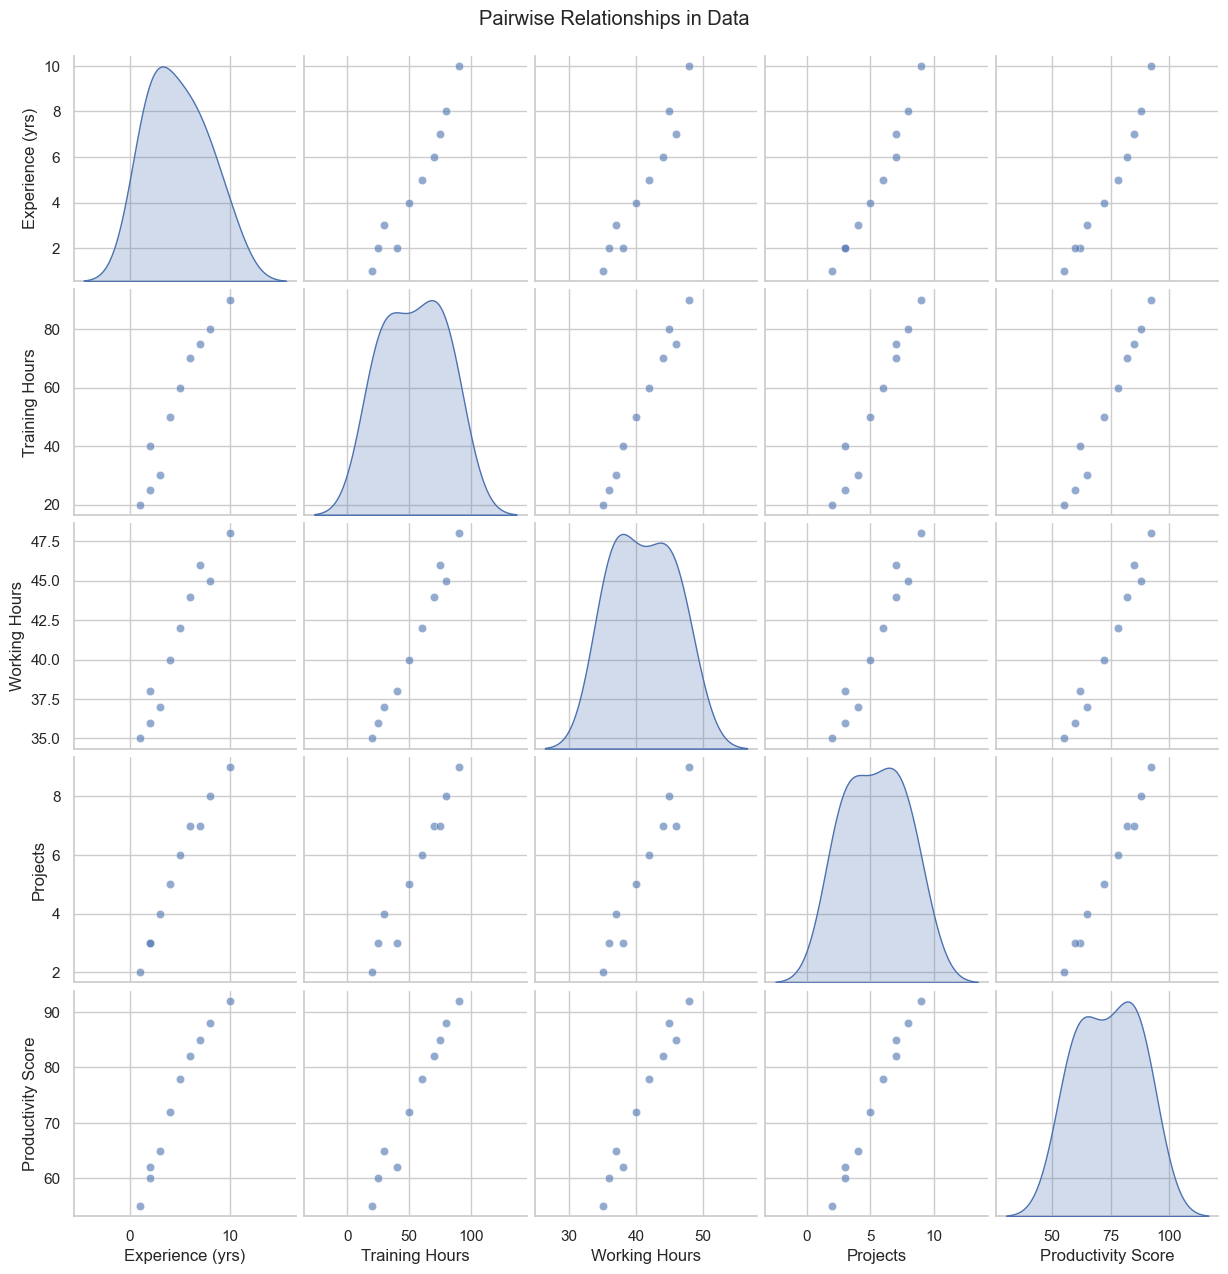

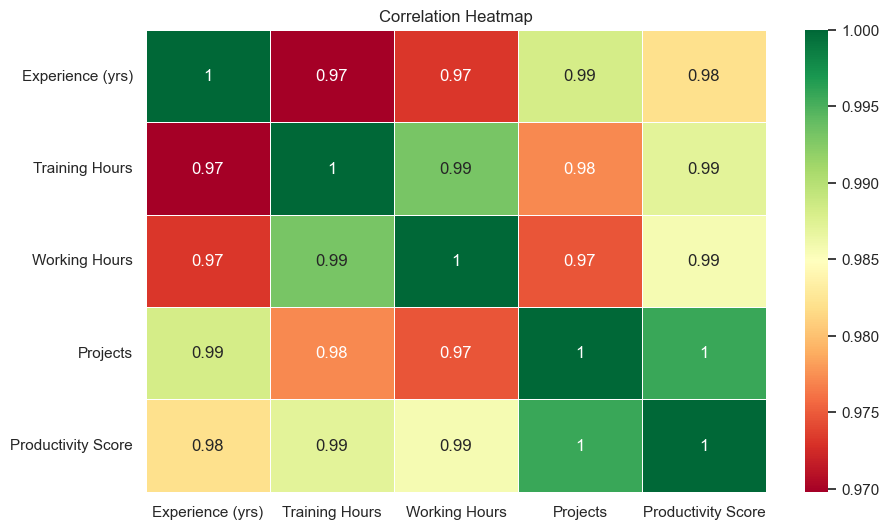

In [7]:
# Creating a Pairplot to see all relationships at once
sns.set(style="whitegrid")
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle("Pairwise Relationships in Data", y=1.02)
plt.show()
# Correlation
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## 3. Model

In [10]:
# Features and Target
X = df[['Experience (yrs)', 'Training Hours', 'Working Hours', 'Projects']]
y = df['Productivity Score']

# Split data into train test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initializing and training the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluation
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Calculating Mean Squared Error
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("--- Model Performance Metrics ---")
print(f"Training R-squared: {train_r2:.4f}")
print(f"Testing R-squared:  {test_r2:.4f}")
print("-" * 33)
print(f"Training MSE:       {train_mse:.4f}")
print(f"Testing MSE:        {test_mse:.4f}")

# Model coefficients
coeffs = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Impact (Coefficients):")
print(coeffs)

--- Model Performance Metrics ---
Training R-squared: 0.9999
Testing R-squared:  0.3146
---------------------------------
Training MSE:       0.0143
Testing MSE:        8.3961

Feature Impact (Coefficients):
                  Coefficient
Experience (yrs)    -0.263658
Training Hours       0.272684
Working Hours       -1.085511
Projects             4.885986


## 4. Interpretations

### **1. Which factor most strongly impacts productivity?**

**Projects.** Based on the correlation matrix, the number of **Projects** has the highest positive correlation coefficient with the Productivity Score. In our regression model, it also carries the largest coefficient. This indicates that the volume of work completed is the most significant predictor of an employee's overall productivity score in this dataset.

### **2. How does training affect productivity?**
There is a strong positive correlation between Training Hours and Productivity. This suggests that as employees spend more time upskilling, their productivity increases. However, the raw coefficient is smaller than "Projects" because Training Hours are measured in tens (20-90) while Projects are in single digits (2-9). It acts as a "force multiplier" for the other factors.

### **3. Should the company increase training hours or working hours?**

Increasing Working Hours shows a numerical increase in productivity in this model.

### **4. What happens if Working Hours increase beyond optimal limits?**

Current model is "Linear," meaning it assumes productivity grows forever as hours increase. In reality, the relationship is usually an "Inverted U."

### **5. Can productivity ever decrease with more experience?**

**Yes, due to "Skill Stagnation" or "Multicollinearity."** In this multiple regression, we see a negative coefficient for Experience. This doesn't mean experience is "bad"; it means that if two employees have the same number of projects and training, the one with less experience might be working more efficiently or using newer methods.

### **6. How would you detect overfitting in this model?**

**Comparing Train vs. Test Performance.** Overfitting happens when a model "memorizes" the noise in the training data rather than learning the pattern.

* The **Training ** is very high (e.g., 0.99).
* The **Testing ** is significantly lower (e.g., 0.31).
In this case, the small dataset (10 rows) makes the model to overfit because it has too few examples to generalize properly.

### **7. Suggest one new feature to improve prediction accuracy.**

**"Quality Metric" or "Error Rate."** Currently, the model focuses on quantity (hours, projects, years). Adding a feature like **"Percentage of Project Rework"** or **"Customer Satisfaction Score"** would provide a more balanced view. An employee might do 10 projects (high productivity score) but if 5 of them have errors, their true value to the company is lower than someone who did 7 perfect projects.